In [1]:
# Import necessary libraries for data analysis and visualization
import numpy as np  # Import numpy for numerical operations
import pandas as pd  # Import pandas for data manipulation and analysis
import matplotlib.pyplot as plt # Import matplotlib.pyplot for data visualization

In [2]:
# Importing the train_test_split function from scikit-learn, which is used to split data into training and testing sets.
from sklearn.model_selection import train_test_split

# Importing SimpleImputer from scikit-learn, which is used for handling missing data by replacing it with a specific value (e.g., mean, median, etc.).
from sklearn.impute import SimpleImputer

# Importing ColumnTransformer from scikit-learn, which is a tool for applying different preprocessing steps to different columns of a dataset.
from sklearn.compose import ColumnTransformer

In [3]:
# Load the dataset from the CSV file
df = pd.read_csv('titanic_toy.csv')

In [4]:
# Display the first 5 rows of the dataframe
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
# Calculate the percentage of missing values for each column
df.isnull().mean() * 100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [6]:
# Dropping the 'Survived' column from the DataFrame 'df' to create the feature set 'X'.
# 'X' will contain all columns except 'Survived', which is assumed to be the target variable.
X = df.drop(columns=['Survived'])

# Extracting the target variable 'Survived' from the DataFrame 'df' to create the label set 'y'.
# 'y' will be a Series containing the values of the 'Survived' column.
y = df['Survived']

In [7]:
# Splitting the dataset into training and testing sets using train_test_split from scikit-learn.
# X_train and X_test are the feature sets for the training and testing datasets, respectively.
# y_train and y_test are the corresponding target values (labels) for training and testing.
# - test_size=0.2 means 20% of the data will be used for testing, and 80% will be used for training.
# - random_state=2 ensures reproducibility of the split by setting a fixed seed for the random number generator.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [8]:
# Creating a new column 'Age_99' in the training set 'X_train'.
# This column replaces missing values (NaN) in the 'Age' column with the value 99.
X_train['Age_99'] = X_train['Age'].fillna(99)

# Creating a new column 'Age_minus1' in the training set 'X_train'.
# This column replaces missing values (NaN) in the 'Age' column with the value -1.
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

# Creating a new column 'Fare_999' in the training set 'X_train'.
# This column replaces missing values (NaN) in the 'Fare' column with the value 999.
X_train['Fare_999'] = X_train['Fare'].fillna(999)

# Creating a new column 'Fare_minus1' in the training set 'X_train'.
# This column replaces missing values (NaN) in the 'Fare' column with the value -1.
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

In [9]:
# Printing the variance of the 'Age' column in the training set before any imputation.
# Variance is a measure of how spread out the values are from the mean.
print('Original Age variable variance: ', X_train['Age'].var())

# Printing the variance of the 'Age_99' column, which is the 'Age' column with NaN values replaced by 99.
print('Age Variance after 99 wala imputation: ', X_train['Age_99'].var())

# Printing the variance of the 'Age_minus1' column, which is the 'Age' column with NaN values replaced by -1.
print('Age Variance after -1 wala imputation: ', X_train['Age_minus1'].var())

# Printing the variance of the 'Fare' column in the training set before any imputation.
print('Original Fare variable variance: ', X_train['Fare'].var())

# Printing the variance of the 'Fare_999' column, which is the 'Fare' column with NaN values replaced by 999.
print('Fare Variance after 999 wala imputation: ', X_train['Fare_999'].var())

# Printing the variance of the 'Fare_minus1' column, which is the 'Fare' column with NaN values replaced by -1.
print('Fare Variance after -1 wala imputation: ', X_train['Fare_minus1'].var())

Original Age variable variance:  204.3495133904614
Age Variance after 99 wala imputation:  951.7275570187172
Age Variance after -1 wala imputation:  318.0896202624484
Original Fare variable variance:  2448.197913706318
Fare Variance after 999 wala imputation:  47219.20265217623
Fare Variance after -1 wala imputation:  2378.5676784883503


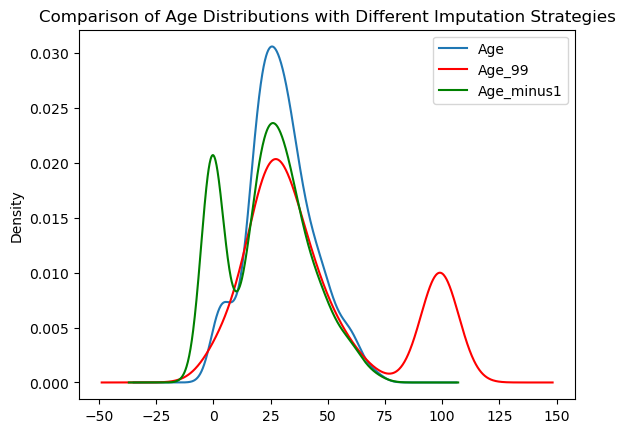

In [10]:
# Creating a figure and adding a subplot to it using Matplotlib.
# The '111' means a single plot (1 row, 1 column, and it's the first plot).
fig = plt.figure()
ax = fig.add_subplot(111)

# Plotting the Kernel Density Estimate (KDE) for the original 'Age' variable.
# KDE is used to estimate the probability density function of the continuous data.
X_train['Age'].plot(kind='kde', ax=ax)

# Plotting the KDE for the 'Age_99' variable (Age with NaN values replaced by 99) in red.
# This shows the distribution after imputing the missing values with 99.
X_train['Age_99'].plot(kind='kde', ax=ax, color='red')

# Plotting the KDE for the 'Age_minus1' variable (Age with NaN values replaced by -1) in green.
# This shows the distribution after imputing the missing values with -1.
X_train['Age_minus1'].plot(kind='kde', ax=ax, color='green')

# Adding legends to the plot to label each line with its corresponding variable.
# 'ax.get_legend_handles_labels()' retrieves the legend handles and labels.
lines, labels = ax.get_legend_handles_labels()

# Adding a title to the graph
ax.set_title('Comparison of Age Distributions with Different Imputation Strategies')

# Displaying the legend at the best location based on the plot's content.
ax.legend(lines, labels, loc='best')

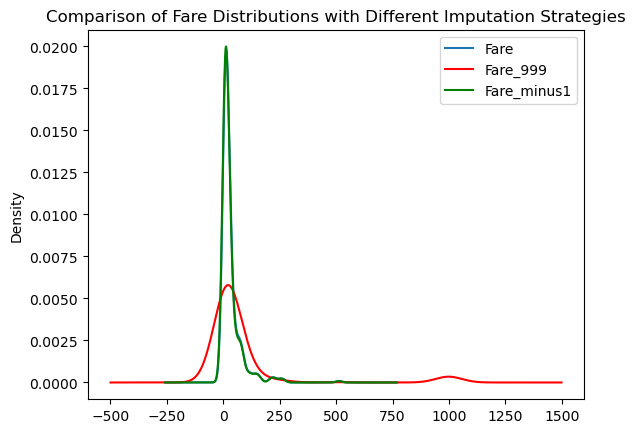

In [11]:
# Creating a new figure object using Matplotlib
fig = plt.figure()

# Adding a single subplot to the figure (1 row, 1 column, 1st plot)
ax = fig.add_subplot(111)

# Plotting the Kernel Density Estimate (KDE) for the original 'Fare' variable.
# This shows the distribution of 'Fare' without imputing missing values.
X_train['Fare'].plot(kind='kde', ax=ax)

# Plotting the KDE for 'Fare_999', which is the 'Fare' column with NaN values replaced by 999, in red.
# This shows how replacing missing values with 999 affects the distribution.
X_train['Fare_999'].plot(kind='kde', ax=ax, color='red')

# Plotting the KDE for 'Fare_minus1', which is the 'Fare' column with NaN values replaced by -1, in green.
# This shows how replacing missing values with -1 affects the distribution.
X_train['Fare_minus1'].plot(kind='kde', ax=ax, color='green')

# Adding legends to the plot to label each line with its corresponding variable.
# 'lines' contains the line objects, and 'labels' contains the associated text.
lines, labels = ax.get_legend_handles_labels()

# Adding a title to the graph
ax.set_title('Comparison of Fare Distributions with Different Imputation Strategies')

# Displaying the legend at the best location based on the plot's content.
ax.legend(lines, labels, loc='best')

In [12]:
# Calculating the covariance matrix for the training dataset 'X_train'.
# The covariance matrix shows the covariance (relationship) between each pair of features (columns) in the dataset.

# - Covariance measures how much two variables change together.
# - A positive covariance indicates that both variables tend to increase or decrease together.
# - A negative covariance indicates that as one variable increases, the other tends to decrease.
# - A covariance of 0 suggests no linear relationship between the variables.

# The result of X_train.cov() is a DataFrame where:
# - Rows and columns represent the features in 'X_train'.
# - Each cell represents the covariance between the corresponding pair of features.
covariance_matrix = X_train.cov()

# You can print the covariance matrix to view it:
print(covariance_matrix)

                    Age         Fare     Family      Age_99  Age_minus1  \
Age          204.349513    70.719262  -6.498901  204.349513  204.349513   
Fare          70.719262  2448.197914  17.258917 -101.671097  125.558364   
Family        -6.498901    17.258917   2.735252   -7.387287   -4.149246   
Age_99       204.349513  -101.671097  -7.387287  951.727557 -189.535540   
Age_minus1   204.349513   125.558364  -4.149246 -189.535540  318.089620   
Fare_999     162.793430  2448.197914  11.528625 -159.931663  257.379887   
Fare_minus1   63.321188  2448.197914  16.553989  -94.317400  114.394141   

                 Fare_999  Fare_minus1  
Age            162.793430    63.321188  
Fare          2448.197914  2448.197914  
Family          11.528625    16.553989  
Age_99        -159.931663   -94.317400  
Age_minus1     257.379887   114.394141  
Fare_999     47219.202652   762.474982  
Fare_minus1    762.474982  2378.567678  


In [13]:
# Calculating the correlation matrix for the training dataset 'X_train'.
# The correlation matrix shows the Pearson correlation coefficients between each pair of features (columns) in the dataset.

# - Correlation measures the strength and direction of the linear relationship between two variables.
# - Values range from -1 to 1:
#   - A value close to 1 indicates a strong positive correlation (as one variable increases, the other also increases).
#   - A value close to -1 indicates a strong negative correlation (as one variable increases, the other decreases).
#   - A value close to 0 indicates little to no linear relationship between the variables.

# The result of X_train.corr() is a DataFrame where:
# - Rows and columns represent the features in 'X_train'.
# - Each cell represents the correlation coefficient between the corresponding pair of features.
correlation_matrix = X_train.corr()

# You can print the correlation matrix to view it:
print(correlation_matrix)

                  Age      Fare    Family    Age_99  Age_minus1  Fare_999  \
Age          1.000000  0.092644 -0.299113  1.000000    1.000000  0.051179   
Fare         0.092644  1.000000  0.208268 -0.066273    0.142022  1.000000   
Family      -0.299113  0.208268  1.000000 -0.144787   -0.140668  0.032079   
Age_99       1.000000 -0.066273 -0.144787  1.000000   -0.344476 -0.023857   
Age_minus1   1.000000  0.142022 -0.140668 -0.344476    1.000000  0.066411   
Fare_999     0.051179  1.000000  0.032079 -0.023857    0.066411  1.000000   
Fare_minus1  0.084585  1.000000  0.205233 -0.062687    0.131514  0.071946   

             Fare_minus1  
Age             0.084585  
Fare            1.000000  
Family          0.205233  
Age_99         -0.062687  
Age_minus1      0.131514  
Fare_999        0.071946  
Fare_minus1     1.000000  


### Using Sklearn

In [14]:
# Splitting the dataset into training and testing sets using train_test_split from scikit-learn.
# X_train and X_test are the feature sets for the training and testing datasets, respectively.
# y_train and y_test are the corresponding target values (labels) for training and testing.
# - test_size=0.2 means 20% of the data will be used for testing, and 80% will be used for training.
# - random_state=2 ensures reproducibility of the split by setting a fixed seed for the random number generator.
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [15]:
# Creating an instance of SimpleImputer to handle missing values using a constant strategy.
# Strategy: 'constant' means missing values (NaN) will be replaced with a fixed value provided by the 'fill_value' parameter.
# fill_value=99: Any missing value will be replaced with 99.
imputer1 = SimpleImputer(strategy='constant', fill_value=99)

# Creating another instance of SimpleImputer for handling missing values using a different constant strategy.
# fill_value=999: Any missing value will be replaced with 999.
imputer2 = SimpleImputer(strategy='constant', fill_value=999)

In [16]:
# Creating an instance of ColumnTransformer to apply different transformations to specific columns in the dataset.

trf = ColumnTransformer([
    # ('imputer1', imputer1, ['Age']):
    # Applies 'imputer1' (SimpleImputer with fill_value=99) to the 'Age' column, replacing NaN values with 99.
    ('imputer1', imputer1, ['Age']),

    # ('imputer2', imputer2, ['Fare']):
    # Applies 'imputer2' (SimpleImputer with fill_value=999) to the 'Fare' column, replacing NaN values with 999.
    ('imputer2', imputer2, ['Fare'])
], 
# remainder='passthrough': Keeps all other columns in the dataset unchanged.
remainder='passthrough')

In [17]:
# Fitting the ColumnTransformer 'trf' to the dataset 'X_train'.

# 'trf' contains two transformers: 'imputer1' for the 'Age' column and 'imputer2' for the 'Fare' column.
# When you call 'fit()', the following happens:
# 1. 'imputer1' is prepared to handle missing values in the 'Age' column, replacing NaN with 99.
# 2. 'imputer2' is prepared to handle missing values in the 'Fare' column, replacing NaN with 999.
#    Note: For 'strategy="constant"', the fit step does not compute statistics; it simply stores the fill value.
# 3. The remainder of the columns ('passthrough') is identified but not processed.

trf.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer2',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

In [18]:
# Accessing the statistics computed by the transformer 'imputer1' inside the ColumnTransformer 'trf'.

# 'trf.named_transformers_' is a dictionary where the keys are the names of the transformers 
# (e.g., 'imputer1' and 'imputer2'), and the values are the corresponding transformer objects.

# 'imputer1' is a SimpleImputer with strategy='constant'. For constant strategy:
# - The SimpleImputer does not compute statistics (like mean or median).
# - Instead, the 'statistics_' attribute will contain the constant value specified during its creation.

# Accessing the 'statistics_' attribute of 'imputer1' will return the constant value [99], which was defined as the fill_value for 'Age'.
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [19]:
trf.named_transformers_['imputer2'].statistics_

array([999.])

In [20]:
# Transforming the training dataset 'X_train' using the fitted ColumnTransformer 'trf'.
# - The 'trf' object applies the transformations specified during its creation.
# - Specifically:
#   - Missing values in the 'Age' column are replaced with 99 (from 'imputer1').
#   - Missing values in the 'Fare' column are replaced with 999 (from 'imputer2').
# - Other columns (as per 'remainder="passthrough"') remain unchanged.

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

X_train = trf.transform(X_train)

# Transforming the testing dataset 'X_test' using the same fitted ColumnTransformer 'trf'.
# - This ensures that the same transformations applied to 'X_train' are consistently applied to 'X_test'.
# - This step is crucial to maintain the same preprocessing steps for both training and testing data.
X_test = trf.transform(X_test)

In [21]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]])